In [203]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [204]:
from sklearn.datasets import load_diabetes
data = load_diabetes(scaled=False)

In [205]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [206]:
data.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [207]:
X= pd.DataFrame(data.data, columns=data.feature_names)
y= pd.Series(data.target,name='disease_progression')

In [208]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0


In [209]:
y

0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: disease_progression, Length: 442, dtype: float64

<Axes: xlabel='bmi', ylabel='disease_progression'>

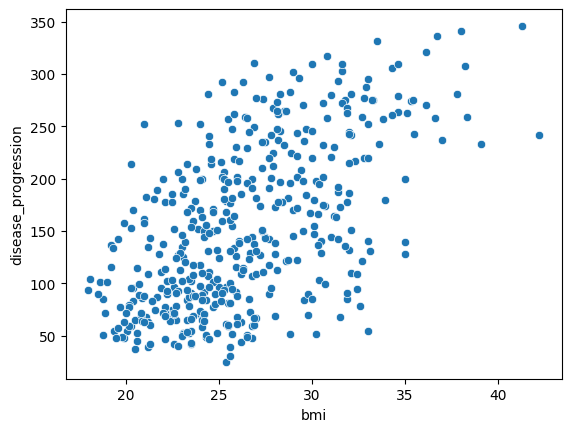

In [210]:
sns.scatterplot(x=X['bmi'],y=y)

Text(0, 0.5, 'disease progression')

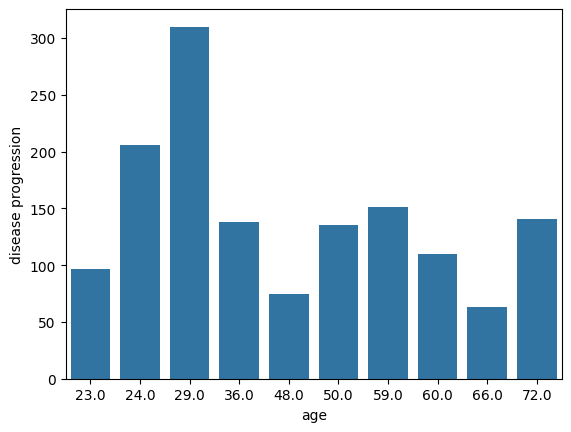

In [211]:
sns.barplot(x=X['age'][:10], y=y[:10])
plt.ylabel('disease progression')

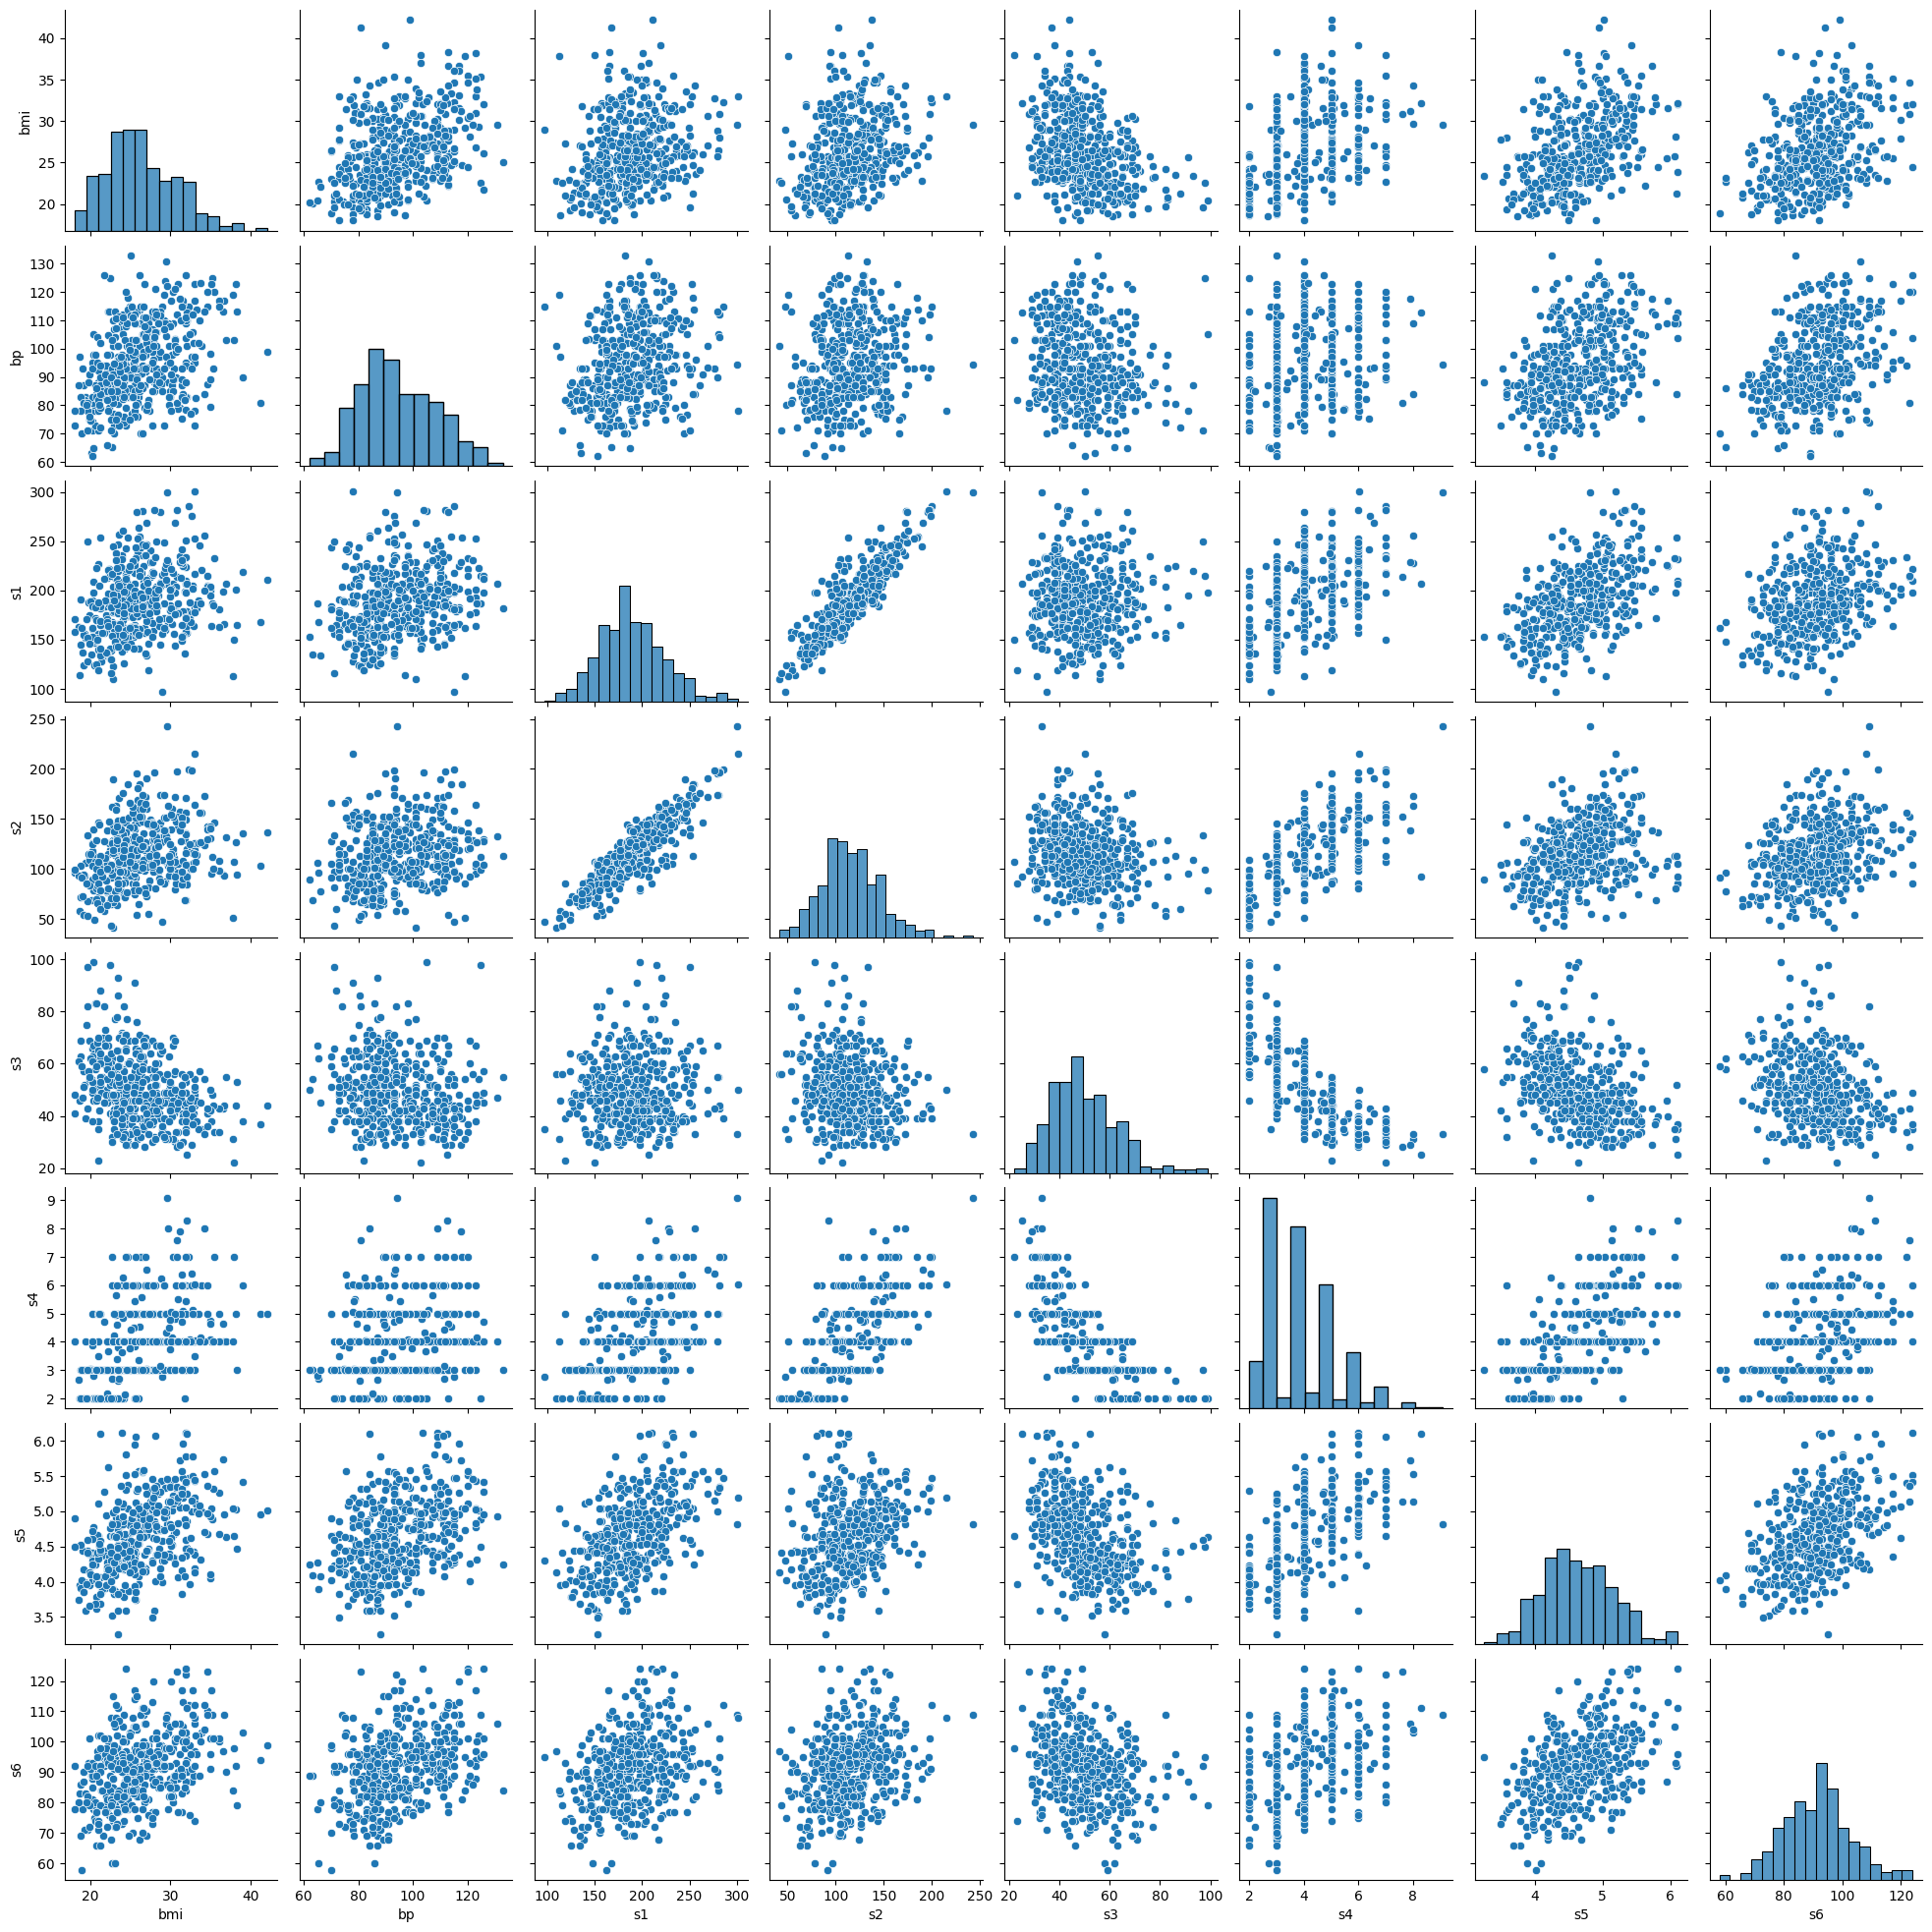

In [212]:
sns.pairplot((X).join(y), vars=['bmi','bp','s1','s2','s3','s4','s5','s6'])

<Axes: xlabel='bmi', ylabel='bp'>

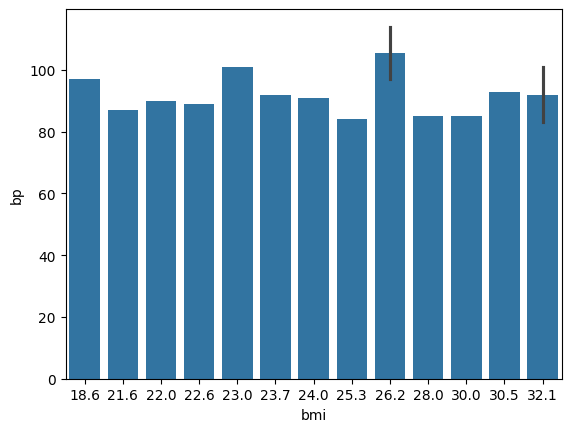

In [213]:
sns.barplot(x=X['bmi'][:15],y=X['bp'])

<Axes: >

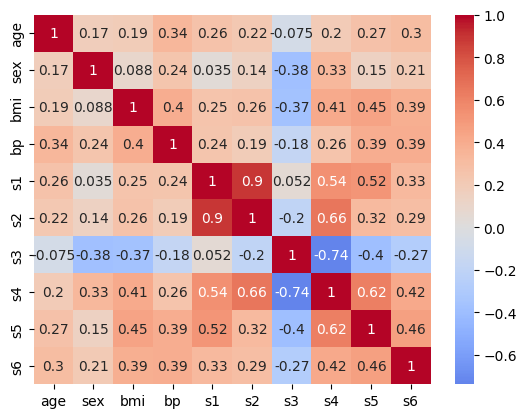

In [214]:
sns.heatmap(X.corr(), annot=True, cmap='coolwarm',center=0)

<Axes: xlabel='age', ylabel='Count'>

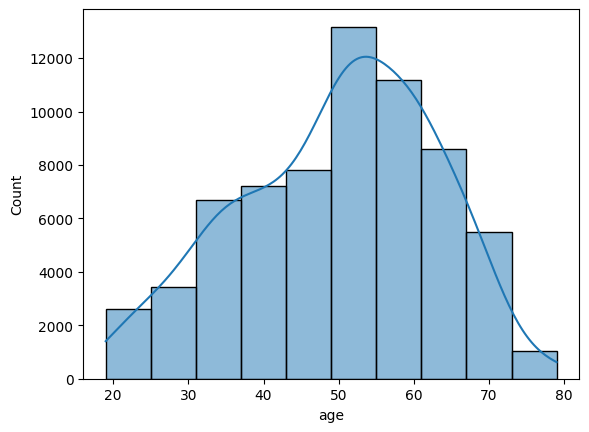

In [215]:
sns.histplot(x=X['age'], kde=True,weights=y,bins=10)

In [216]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [220]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])
pipeline.fit(X_train,y_train)
ypred=pipeline.predict(X_test)
score=r2_score(y_test,ypred)
print('score :',score)


score : 0.46687670944102455


In [218]:
# the 'lasso__'  this tells the grid search which step to apply params to
params = {
    'lasso__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'lasso__max_iter': [1000, 5000],
    'lasso__selection': ['cyclic', 'random'],
    'lasso__tol': [0.0001, 0.001] # for the small decimals, not max_iter
}

grid = GridSearchCV(
    estimator=pipeline, 
    param_grid=params, 
    scoring='r2', 
    cv=5, 
    n_jobs=-1  
)

grid.fit(X_train, y_train)

print(f"Best R2 Score: {grid.best_score_}")
print(f"Best Parameters: {grid.best_params_}")

Best R2 Score: 0.45425125241407305
Best Parameters: {'lasso__alpha': 1, 'lasso__max_iter': 5000, 'lasso__selection': 'random', 'lasso__tol': 0.001}


In [219]:
pred=[[34,1,29,98,151,93.2,31,4,4.8598,87.2]]   ## age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
a=pipe.predict(pred)
print("the prediction of this dataset is :",a)

the prediction of this dataset is : [209.67421278]


C:\Users\burha\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Note on Dataset Choice

This notebook applies Lasso Regression to a new dataset to observe how
feature selection behavior generalizes beyond earlier experiments.
The goal is analysis and understanding, not model optimization.
